In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.optimize import brentq

import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_theme()

# Load Data

In [2]:
INPUT_COLS = ["S0","taus","rs","sigma"]
OUTPUT_COL = ["price"]

DATA_DIR = "data"
CHECKPOINT_DIR = "checkpoints"

In [3]:
df = pd.read_csv(f"{DATA_DIR}/synthetic_data-bs.csv")
df = df.dropna()

mask = (
    (df["price"] >= 0) &
    (df["price"] <= df["S0"])
)
df = df[mask]

low, high = df["price"].quantile([0.001, 0.999])
df = df[(df["price"] >= low) & (df["price"] <= high)]

mu = df["price"].mean()
sigma = df["price"].std()

df = df[np.abs((df["price"] - mu) / sigma) < 5]

In [4]:
X = df[INPUT_COLS].values.astype('float32')
y = df[OUTPUT_COL].values.astype('float32')

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, train_size=0.8, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=42
)

# Prepare Classes

In [5]:
class NN(nn.Module):
    def __init__(self, input_dim, hidden_neurons=400, n_hidden=4, activation=nn.ReLU, use_bn=False):
        super().__init__()
        layers = []
        in_dim = input_dim
        
        for _ in range(n_hidden):
            layers.append(nn.Linear(in_dim, hidden_neurons))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_neurons))
            layers.append(activation())
            in_dim = hidden_neurons
        
        layers.append(nn.Linear(in_dim, out_features=1))
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def forward(self, x):
        return self.net(x)

class PINN(nn.Module):
    def __init__(self, input_dim, hidden_neurons=50, n_hidden=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_neurons), activation()]
        for _ in range(n_hidden - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(activation())
        layers.append(nn.Linear(hidden_neurons, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class PricingPINN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=4):
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]

        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.output_layer(self.network(x)).squeeze(-1)

activation_map = {
    "relu": nn.ReLU,
    "elu": nn.ELU,
    "tanh": nn.Tanh,
    "silu": nn.SiLU,        # aka Swish
    "softplus": nn.Softplus
}

# Load models

In [6]:
def load_ann():
    with open(f"{CHECKPOINT_DIR}/config_nn.json") as f:
        config = json.load(f)

    model = NN(
        input_dim=X.shape[1],
        hidden_neurons=config["hidden_neurons"],
        activation=activation_map[config["activation"]],
        use_bn=config["use_bn"]
    )

    model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/nn_price.pth"))
    model.eval()

    xsc = joblib.load(f"{CHECKPOINT_DIR}/xsc_nn.pkl")
    ysc = joblib.load(f"{CHECKPOINT_DIR}/ysc_nn.pkl")
    return model, xsc, ysc

def load_pinn():
    with open(f"{CHECKPOINT_DIR}/config_pinn.json") as f:
        config = json.load(f)
    
    model = PricingPINN(
        input_dim=X.shape[1],
        hidden_dim=config["hidden_neurons"],
        num_layers=config["n_hidden"]
    )

    model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/pinn_price.pth"))
    model.eval()

    xsc = joblib.load(f"{CHECKPOINT_DIR}/xsc_pinn.pkl")
    ysc = joblib.load(f"{CHECKPOINT_DIR}/ysc_pinn.pkl")
    return model, xsc, ysc

In [7]:
model_nn, xsc_nn, ysc_nn = load_ann()
model_pinn, xsc_pinn, ysc_pinn = load_pinn()

/Users/jakubkempa/.virtualenvs/genenv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Model Predict functions

In [8]:
def predict(model, X, xsc, ysc, batch_size=2048):
    model.eval()
    Xs = xsc.transform(X)
    preds = []

    with torch.no_grad():
        for i in range(0, len(Xs), batch_size):
            xb = torch.from_numpy(Xs[i:i+batch_size]).float()
            yb = model(xb).numpy()
            preds.append(yb.reshape(-1, 1))

    preds = np.vstack(preds)
    return ysc.inverse_transform(preds).ravel()

# Calculate and plot model diagnostics

In [9]:
y_true = y_test.ravel()
y_pred_nn = predict(model_nn, X_test, xsc_nn, ysc_nn)
resid_nn = y_pred_nn - y_true
r2_nn = r2_score(y_true, y_pred_nn)

y_pred_pinn = predict(model_pinn, X_test, xsc_pinn, ysc_pinn)
resid_pinn = y_pred_pinn - y_true
r2_pinn = r2_score(y_true, y_pred_pinn)

## $R^2$ plot

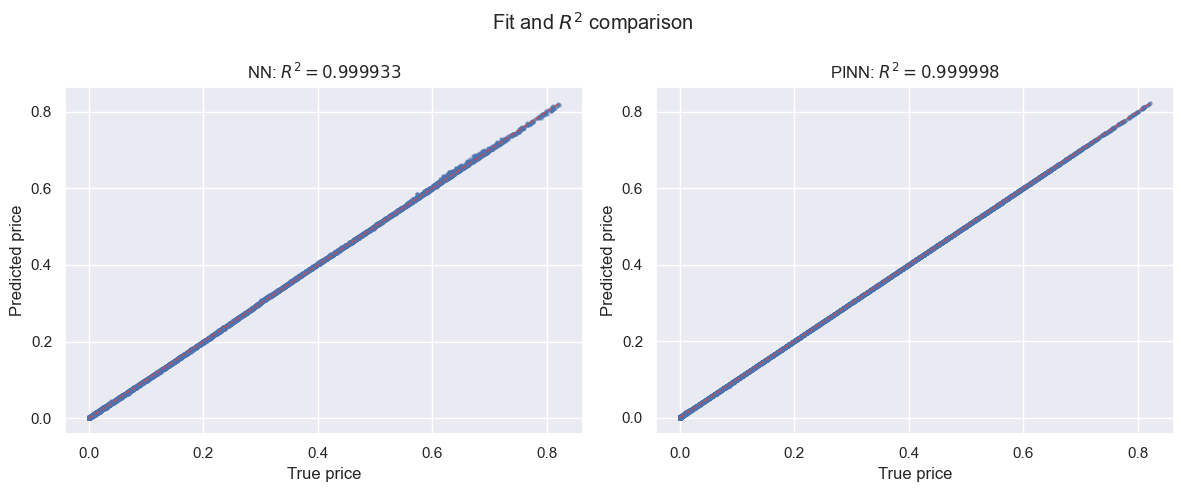

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle(fr"Fit and $R^2$ comparison")

# Predicted vs True
ax[0].scatter(y_true, y_pred_nn, s=5, alpha=0.5)
lims = [0, max(y_true.max(), y_pred_nn.max())]
ax[0].plot(lims, lims, 'r--', lw=1)
ax[0].set_xlabel("True price")
ax[0].set_ylabel("Predicted price")
ax[0].set_title(rf"NN: $R^2 = {r2_nn:6f}$")

ax[1].scatter(y_true, y_pred_pinn, s=5, alpha=0.5)
lims = [0, max(y_true.max(), y_pred_pinn.max())]
ax[1].plot(lims, lims, 'r--', lw=1)
ax[1].set_xlabel("True price")
ax[1].set_ylabel("Predicted price")
ax[1].set_title(rf"PINN: $R^2 = {r2_pinn:6f}$")

plt.tight_layout()
plt.show()

## Residuals comparison

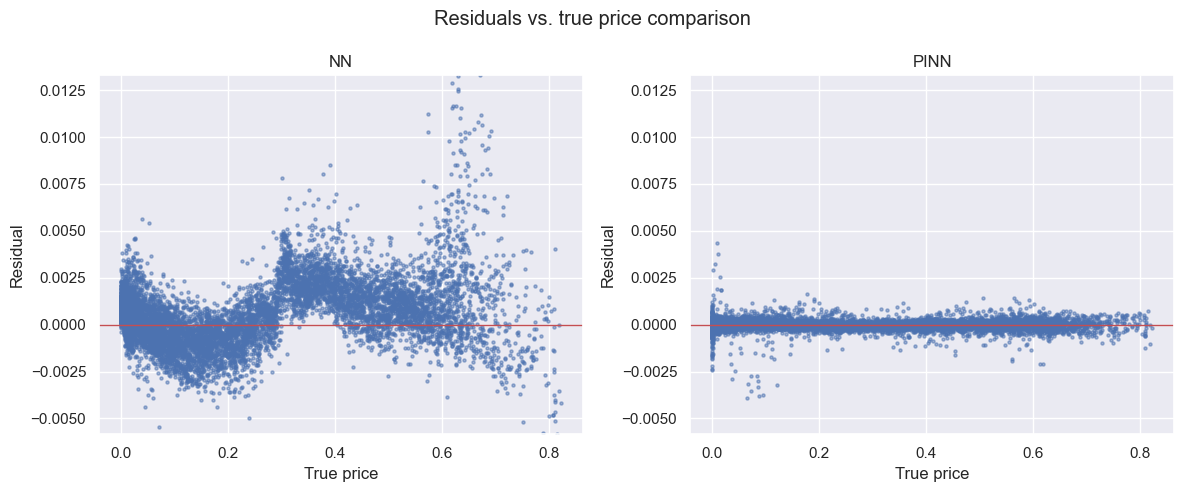

In [11]:
ymin = min(min(resid_nn), min(resid_pinn))
ymax = max(max(resid_nn), max(resid_pinn))

fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle("Residuals vs. true price comparison")

ax[0].scatter(y_true, resid_nn, s=5, alpha=0.5)
ax[0].axhline(0, color="r", lw=1)
ax[0].set_xlabel("True price")
ax[0].set_ylabel("Residual")
ax[0].set_title("NN")
ax[0].axis(ymin=ymin, ymax=ymax)

ax[1].scatter(y_true, resid_pinn, s=5, alpha=0.5)
ax[1].axhline(0, color="r", lw=1)
ax[1].set_xlabel("True price")
ax[1].set_ylabel("Residual")
ax[1].set_title("PINN")
ax[1].axis(ymin=ymin, ymax=ymax)

plt.tight_layout()
plt.show()

## Residual distribution

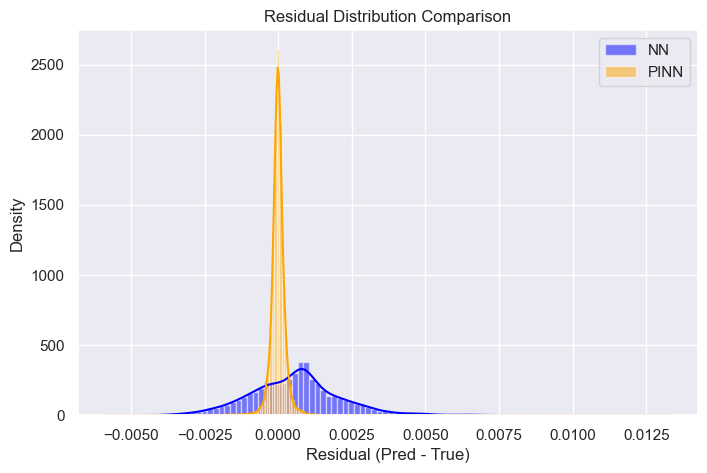

In [12]:
x_range = np.linspace(ymin, ymax, 500)

plt.figure(figsize=(8, 5))

plt.hist(resid_nn, bins="sqrt", density=True, alpha=0.5, color='blue', label='NN')
plt.plot(x_range, st.gaussian_kde(resid_nn)(x_range), color='blue')

plt.hist(resid_pinn, bins="sqrt", density=True, alpha=0.5, color='orange', label='PINN')
plt.plot(x_range, st.gaussian_kde(resid_pinn)(x_range), color='orange')

plt.xlabel("Residual (Pred - True)")
plt.ylabel("Density")
plt.title("Residual Distribution Comparison")
plt.legend()
plt.show()

## QQ-plot

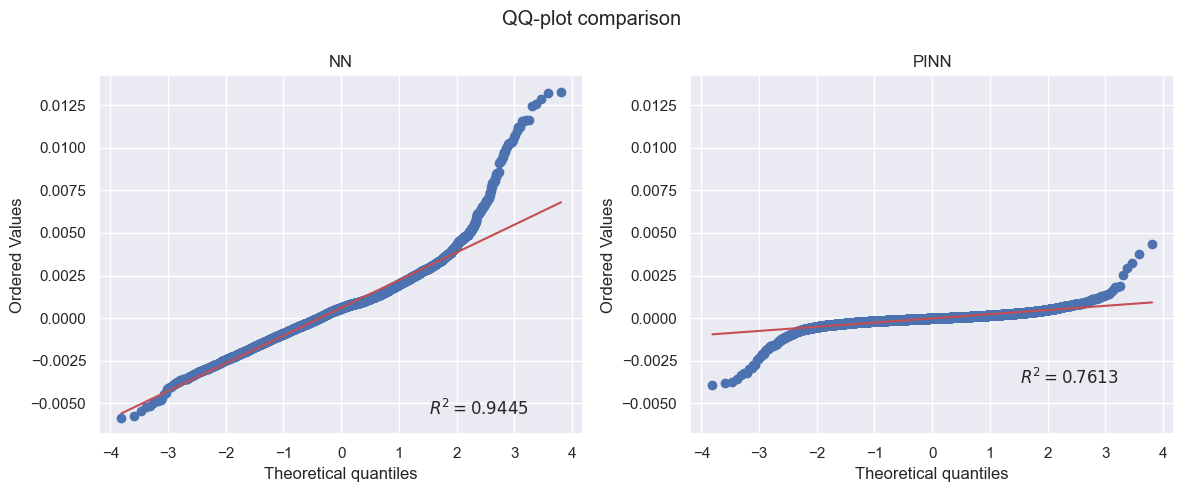

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle("QQ-plot comparison")

st.probplot(resid_nn, dist="norm", plot=ax[0], rvalue=True)
ax[0].set_title("NN")
st.probplot(resid_pinn, dist="norm", plot=ax[1], rvalue=True)
ax[1].set_title("PINN")

ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

# Implied Volatility

In [14]:
def pinn_price(model, S, T, r, sigma, xsc, ysc):
    X = np.column_stack([S, T, r, sigma])
    X_scaled = xsc.transform(X)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        C_scaled = model(X_tensor).cpu().numpy()

    C_scaled = C_scaled.reshape(-1, 1)

    price = ysc.inverse_transform(C_scaled)[0, 0]
    return float(price)

def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * st.norm.cdf(d1) - K * np.exp(-r * T) * st.norm.cdf(d2)

def implied_volatility_call(price, S, K, T, r):
    if price < max(S - K * np.exp(-r*T), 0):
        return np.nan

    def objective(sigma):
        return bs_call_price(S, K, T, r, sigma) - price

    try:
        return brentq(objective, 1e-6, 5.0, maxiter=200)
    except ValueError:
        return np.nan

In [15]:
def draw_iv_surfaces(T_mesh, S_mesh, IV_surface_nn, IV_surface_pinn, title):
    fig = plt.figure(figsize=(12, 6))
    fig.suptitle(title)
    ax1 = fig.add_subplot(121, projection="3d")
    ax2 = fig.add_subplot(122, projection="3d")

    ax1.plot_surface(
        T_mesh, S_mesh, IV_surface_nn,
        cmap="viridis",
        linewidth=0,
        antialiased=True
    )

    ax1.set_xlabel("Time to maturity T")
    ax1.set_ylabel("Spot price S")
    ax1.set_zlabel("Implied volatility")
    ax1.set_title("NN model")

    ax2.plot_surface(
        T_mesh, S_mesh, IV_surface_pinn,
        cmap="viridis",
        linewidth=0,
        antialiased=True
    )

    ax2.set_xlabel("Time to maturity T")
    ax2.set_ylabel("Spot price S")
    ax2.set_title("PINN model")
    ax1.set_zlabel("Implied volatility", labelpad=5)
    plt.tight_layout()
    plt.show()

## Implied Volatility for long maturities

In [16]:
S_grid = np.linspace(0.8, 1.2, 40)
T_grid = np.linspace(0.5, 2.5, 40)

S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

r_val = 0.03
sigma_ref = 0.25
K = 1.0

In [17]:
IV_surface_nn = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        price = pinn_price(
            model_nn,
            np.array([S]),
            np.array([T]),
            np.array([r_val]),
            np.array([sigma_ref]),
            xsc_nn, ysc_nn
        )

        IV_surface_nn[i, j] = implied_volatility_call(
            price, S, K, T, r_val
        )

In [18]:
IV_surface_pinn = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        price = pinn_price(
            model_pinn,
            np.array([S]),
            np.array([T]),
            np.array([r_val]),
            np.array([sigma_ref]),
            xsc_pinn, ysc_pinn
        )

        IV_surface_pinn[i, j] = implied_volatility_call(
            price, S, K, T, r_val
        )

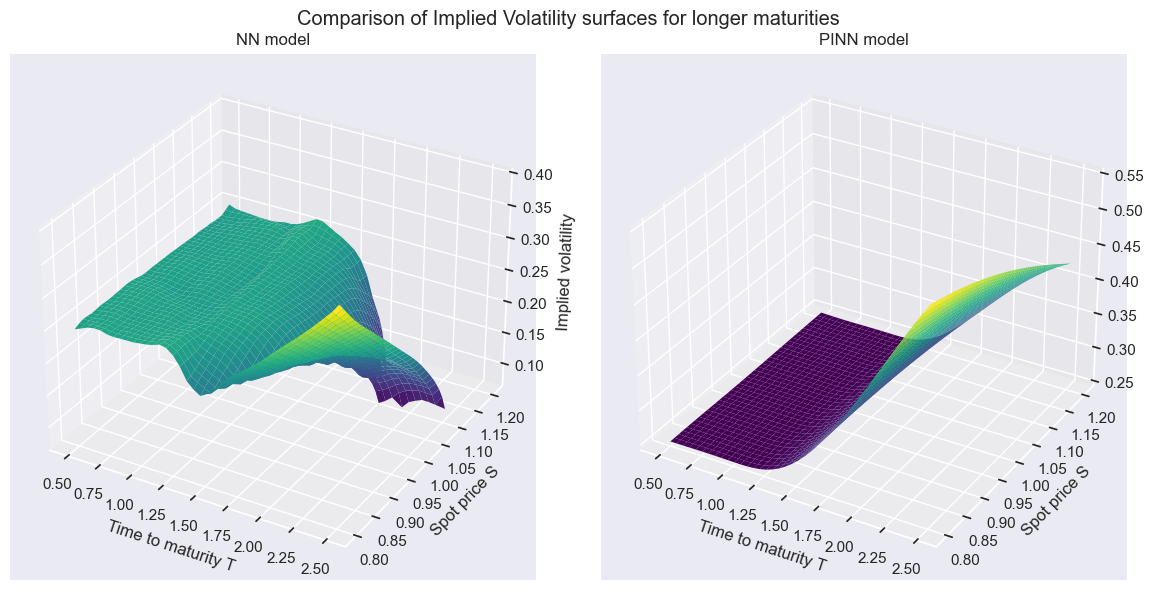

In [19]:
draw_iv_surfaces(
    T_mesh, S_mesh, 
    IV_surface_nn, IV_surface_pinn,
    title="Comparison of Implied Volatility surfaces for longer maturities"
)

## Implied Volatility for shorter maturities

In [20]:
S_grid = np.linspace(0.8, 1.2, 40)
T_grid = np.linspace(0.5, 1.5, 40)

S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)

r_val = 0.03
sigma_ref = 0.25
K = 1.0

In [21]:
IV_surface_nn = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        price = pinn_price(
            model_nn,
            np.array([S]),
            np.array([T]),
            np.array([r_val]),
            np.array([sigma_ref]),
            xsc_nn, ysc_nn
        )

        IV_surface_nn[i, j] = implied_volatility_call(
            price, S, K, T, r_val
        )

In [22]:
IV_surface_pinn = np.zeros_like(S_mesh)

for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        S = S_mesh[i, j]
        T = T_mesh[i, j]

        price = pinn_price(
            model_pinn,
            np.array([S]),
            np.array([T]),
            np.array([r_val]),
            np.array([sigma_ref]),
            xsc_pinn, ysc_pinn
        )

        IV_surface_pinn[i, j] = implied_volatility_call(
            price, S, K, T, r_val
        )

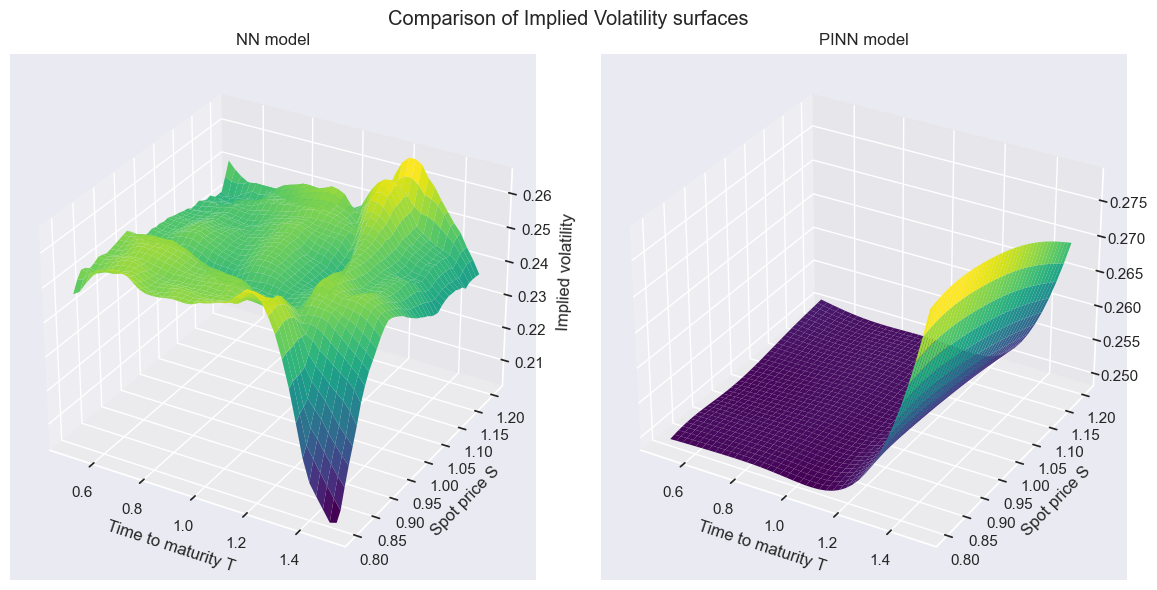

In [23]:
draw_iv_surfaces(
    T_mesh, S_mesh, 
    IV_surface_nn, IV_surface_pinn,
    title="Comparison of Implied Volatility surfaces"
)